# Continuous-Time Derivative Pricing Assignment 2026

This notebook contains the solutions to the assignment tasks. It also includes additional material that goes beyond what is shown on the poster, such as more detailed explanations, derivations, and implementation notes.

All figures used in the poster are stored in the `figs/` folder. Further information is provided in the respective sections where needed.


In [1]:
# necessary imports
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from cycler import cycler
from tueplots import bundles
from tueplots import axes, fonts, fontsizes
from tueplots.constants.color import palettes

import pandas as pd
from src.utils import load_svensson_params 

from datetime import datetime

from src.valuation import (
    nelson_siegel_svensson_model,
    zero_to_short,
    idx_of,
    price_express_certificate_one_day,
    price_and_greeks,
    price_and_extended_greeks,
    error_metrics,
)

from scipy.signal import savgol_filter
import matplotlib.dates as mdates

### Plot styling

In [2]:
# General style settings
style = bundles.beamer_moml()
plt.rcParams.update(style)

# Adjust font sizes
plt.rcParams['axes.labelsize'] = 16    # x and y labels
plt.rcParams['xtick.labelsize'] = 13   # tick labels
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13   # match tick sizes
plt.rcParams['font.size'] = 13

# Ensure font aligment
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})


## Part 1

The following code cell contains the implementation for Task III, Product Payoff.

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/2939828332.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


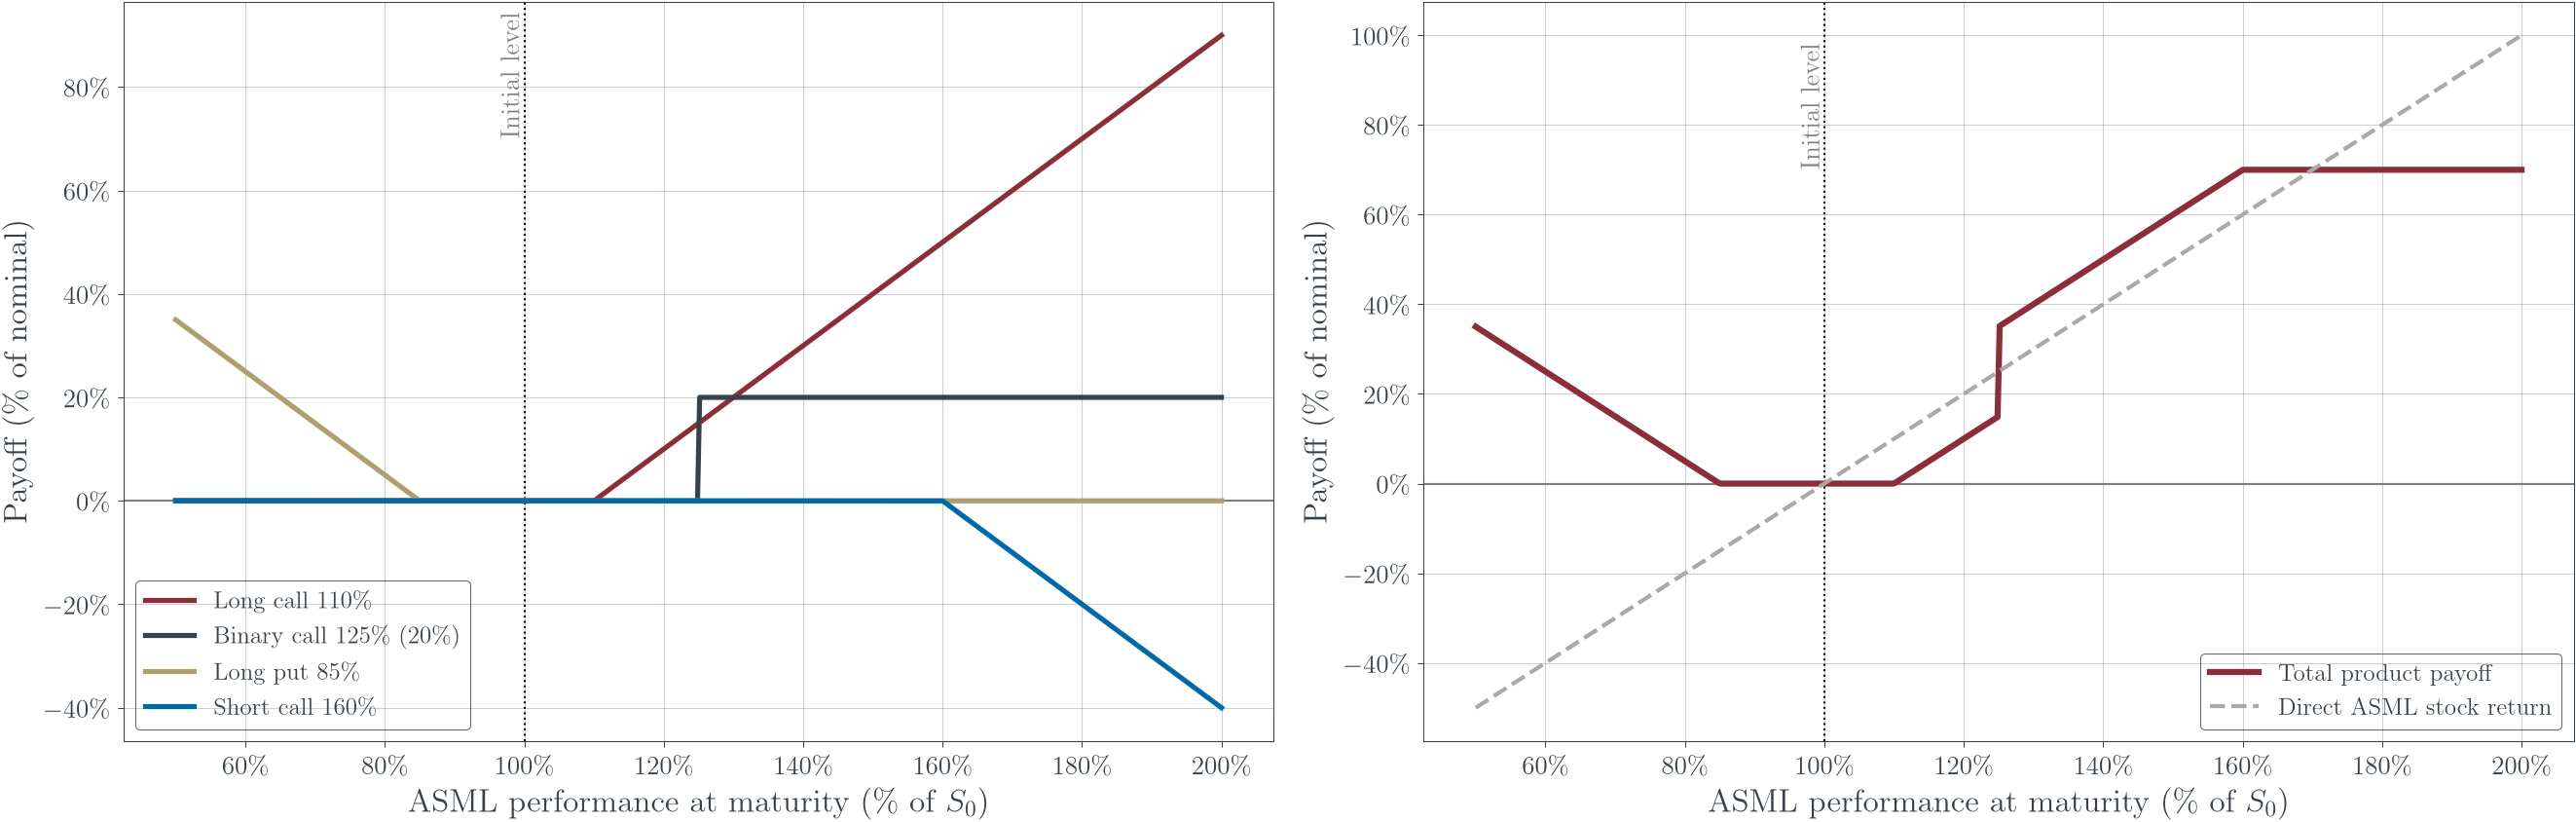

In [3]:
# ASML Growth Buffer Certificate

# Normalized ASML initial level
# S0 = 100 means all strikes are expressed as % of initial ASML price
S0 = 100
x = np.linspace(0.5 * S0, 2.0 * S0, 500)

# Strike prices
k_call = 1.10 * S0      # long call strike: 110%
k_digi = 1.25 * S0      # digital call trigger: 125%
k_put = 0.85 * S0       # protective put strike: 85%
k_cap = 1.60 * S0       # short call cap: 160%

# Product parameter
digi_pay = 0.20 * S0    # fixed digital payoff: 20% of nominal

# Individual payoff components
vanilla_call = np.maximum(0, x - k_call)
digital_call = np.where(x >= k_digi, digi_pay, 0)
protective_put = np.maximum(0, k_put - x)
short_cap_call = -np.maximum(0, x - k_cap)

# Gross product payoff
total_payoff = (
    vanilla_call
    + digital_call
    + protective_put
    + short_cap_call
)

# Relative payoff / return
rel = lambda arr: arr / S0
rel_stock = (x - S0) / S0

# Plot
fig, axs = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

# Left plot

axs[0].axvline(S0, ls=":", color="black", lw=1)
axs[0].axhline(0, color="grey", lw=1)

axs[0].text(
    S0, 0.70,
    "Initial level",
    rotation=90,
    va="bottom",
    ha="right",
    color="gray"
)

axs[0].plot(x, rel(vanilla_call), label=r"Long call 110\%", lw=2.5)
axs[0].plot(x, rel(digital_call), label=r"Binary call 125\% (20\%)", lw=2.5)
axs[0].plot(x, rel(protective_put), label=r"Long put 85\%", lw=2.5)
axs[0].plot(x, rel(short_cap_call), label=r"Short call 160\%", lw=2.5)

axs[0].set_xlabel(r"ASML performance at maturity (\% of $S_0$)")
axs[0].set_ylabel(r"Payoff (\% of nominal)")
axs[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axs[0].legend(fontsize=12, loc="lower left")
axs[0].grid(alpha=0.25)

# Right plot

axs[1].axvline(S0, ls=":", color="black", lw=1)
axs[1].axhline(0, color="grey", lw=1)

axs[1].text(
    S0, 0.70,
    "Initial level",
    rotation=90,
    va="bottom",
    ha="right",
    color="gray"
)

axs[1].plot(
    x,
    rel(total_payoff),
    lw=3,
    label="Total product payoff"
)

axs[1].plot(
    x,
    rel_stock,
    ls="--",
    lw=2,
    color="darkgrey",
    label="Direct ASML stock return"
)

axs[1].set_xlabel(r"ASML performance at maturity (\% of $S_0$)")
axs[1].set_ylabel(r"Payoff (\% of nominal)")
axs[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axs[1].legend(loc="lower right", fontsize=12)
axs[1].grid(alpha=0.25)

plt.tight_layout()

# Save figure
plt.savefig("figs/part1_payoff.pdf", bbox_inches="tight")

plt.show()

## Part 2

The following code cells deal with data loading, setup and, preprocessing.

In [4]:
# Paths for ASML underlying, traded certificate, and Svensson parameter data
UNDERLYING_DATA_PATH = "./data/asml.csv"
CERTIFICATE_DATA_PATH = "./data/asml_express.csv"
SVENSSON_PARAMS_PATH = "./data/svensson_params/"

# Valuation window
START_DATE_VALUATION = "2025-12-15"
END_DATE_VALUATION = "2026-06-15"

# Constants
TRADING_DAYS = 252
VOL_WINDOW = 252

In [5]:
PRODUCT_PARAMS = {
    "S_START": 682.50,
    "NOMINAL": 1000.0,
    "BARRIER": 443.625,
    "BASIS_PRICE": 682.50,
    "MAX_AMOUNT": 1358.50,
    "SHARES": 1.465201,

    "LEVELS": (
        682.50,     # 100% of inital reference price
        648.375,    # 95% of initial reference price
    ),

    "OBS_DATES": (
        datetime(2026, 6, 24),
        datetime(2027, 6, 24),
    ),

    "EARLY_REDEMPTION_DATES": (
        datetime(2026, 7, 1),
        datetime(2027, 7, 1),
    ),

    "EARLY_REDEMPTION_AMOUNTS": (
        1119.50,
        1239.00,
    ),

    "FINAL_OBS_DATE": datetime(2028, 6, 26),
    "MATURITY": datetime(2028, 7, 3),

    "TRADING_DAYS": 252,
    "STEPS_PER_DAY": 252 / 365,
}

In [6]:
# Load ASML underlying data and normalize the German-formatted price columns
asml_df = pd.read_csv(UNDERLYING_DATA_PATH, delimiter=";")

# Convert German number format to floats
price_cols = ["Eröffnung", "Hoch", "Tief", "Schluss"]

for col in price_cols:
    asml_df[col] = (
        asml_df[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace({"-": np.nan})
        .astype(float)
    )

# Parse and sort date column
asml_df["Datum"] = pd.to_datetime(asml_df["Datum"], dayfirst=True)
asml_df = asml_df.sort_values("Datum").reset_index(drop=True)

# Calculate log returns and one-year rolling historical volatility
asml_df["log_return"] = np.log(asml_df["Schluss"] / asml_df["Schluss"].shift(1))
asml_df["hist_volatility"] = (
    asml_df["log_return"]
    .rolling(window=VOL_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

asml_df = asml_df.rename(columns={"Schluss": "underlying_price"})

In [7]:
# Load Svensson parameter data
svensson_df = load_svensson_params(SVENSSON_PARAMS_PATH)

# Keep only dates relevant for the available ASML data
latest_date = asml_df["Datum"].max()
cutoff_date = latest_date - pd.Timedelta(days=365 * 3)
svensson_df = svensson_df[svensson_df["Datum"] >= cutoff_date].copy()

# Merge latest available Svensson parameters into ASML data
asml_df = pd.merge(
    asml_df,
    svensson_df,
    on="Datum",
    how="left"
)

In [ ]:
# Load traded Express Plus Certificate data and normalize the quoted prices
certificate_df = pd.read_csv(CERTIFICATE_DATA_PATH, delimiter=";")

price_cols = ["Eröffnung", "Hoch", "Tief", "Schluss"]

for col in price_cols:
    certificate_df[col] = (
        certificate_df[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace({"-": np.nan})
        .astype(float)
    )

certificate_df["Datum"] = pd.to_datetime(certificate_df["Datum"], dayfirst=True)
certificate_df = certificate_df.sort_values("Datum").reset_index(drop=True)

certificate_df = certificate_df.rename(columns={"Schluss": "certificate_quote"})

# Convert quoted levels to EUR only when the source file stores percentage-of-nominal values.
if certificate_df["certificate_quote"].median() < 200:
    certificate_df["certificate_price_eur"] = (
        certificate_df["certificate_quote"] / 100 * PRODUCT_PARAMS["NOMINAL"]
    )
else:
    certificate_df["certificate_price_eur"] = certificate_df["certificate_quote"]

display(certificate_df[["Datum", "certificate_quote", "certificate_price_eur"]].head())
display(certificate_df[["Datum", "certificate_quote", "certificate_price_eur"]].tail())

,Datum,certificate_quote,certificate_price_eur
0,2025-07-01,975.56,975.56
1,2025-07-02,980.23,980.23
2,2025-07-03,979.43,979.43
3,2025-07-04,983.90,983.90
4,2025-07-07,975.00,975.00


,Datum,certificate_quote,certificate_price_eur
237,2026-06-09,1101.46,1101.46
238,2026-06-10,1101.52,1101.52
239,2026-06-11,1107.28,1107.28
240,2026-06-12,1101.77,1101.77
241,2026-06-15,1085.15,1085.15


In [ ]:
# Filter ASML and certificate data to valuation window
asml_val = asml_df[
    (asml_df["Datum"] >= START_DATE_VALUATION)
    & (asml_df["Datum"] <= END_DATE_VALUATION)
].copy()

certificate_val = certificate_df[
    (certificate_df["Datum"] >= START_DATE_VALUATION)
    & (certificate_df["Datum"] <= END_DATE_VALUATION)
].copy()

# Keep only relevant columns
asml_val = asml_val[
    [
        "Datum",
        "underlying_price",
        "log_return",
        "hist_volatility",
        "beta0",
        "beta1",
        "beta2",
        "beta3",
        "tau1",
        "tau2",
    ]
]

certificate_val = certificate_val[
    [
        "Datum",
        "certificate_quote",
        "certificate_price_eur",
    ]
]

# Merge underlying, volatility, interest-rate parameters, and certificate prices
valuation_df = certificate_val.merge(asml_val, on="Datum", how="inner")

print("Start date:", valuation_df["Datum"].min().date())
print("End date:", valuation_df["Datum"].max().date())
print("Matched trading days:", len(valuation_df))
print("Missing volatility values:", valuation_df["hist_volatility"].isna().sum())
print(
    "Missing Svensson rows:",
    valuation_df[["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]]
    .isna()
    .any(axis=1)
    .sum()
)

assert len(valuation_df) >= 100
assert valuation_df["hist_volatility"].notna().all()
assert valuation_df[["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]].notna().all().all()

valuation_df.head()

Start date: 2025-12-15
End date: 2026-06-15
Matched trading days: 123
Missing volatility values: 0
Missing Svensson rows: 0


,Datum,certificate_quote,certificate_price_eur,underlying_price,log_return,hist_volatility,beta0,beta1,beta2,beta3,tau1,tau2
0,2025-12-15,1055.90,1055.90,931.0,0.006141,0.370803,3.04078,-1.07659,-28.00579,29.79871,6.53932,7.01400
1,2025-12-16,1036.68,1036.68,908.6,-0.024354,0.369647,3.04396,-1.09201,-27.96620,29.79781,6.52465,7.00377
2,2025-12-17,1020.71,1020.71,874.0,-0.038825,0.371714,3.22756,-1.27380,-27.99328,29.26908,6.04106,6.45765
3,2025-12-18,1045.90,1045.90,892.7,0.021170,0.372237,3.21586,-1.25945,-27.96469,29.26939,6.01899,6.45084
4,2025-12-19,1036.50,1036.50,901.6,0.009920,0.372298,3.33618,-1.37535,-28.09423,29.27057,5.95697,6.36344


### Part 2, Task V

The following code cells contain the implementation for Task V, Valuation.

In [10]:
# Initialize lists for daily model prices and their corresponding valuation dates
daily_prices = []
valuation_dates = []

# Value the certificate separately on each trading day in the valuation window
for _, row in valuation_df.iterrows():
    # Extract the current valuation date, underlying price, and volatility estimate
    val_date = row["Datum"].to_pydatetime()
    spot = row["underlying_price"]
    sigma = row["hist_volatility"]

    # Extract the Nelson-Siegel-Svensson parameters observed on the valuation date
    b0, b1, b2, b3, t1, t2 = row[
        ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
    ]

    # Determine the number of remaining trading days until product maturity
    n_steps = idx_of(PRODUCT_PARAMS["MATURITY"], val_date, PRODUCT_PARAMS)

    # Construct year-fraction maturities for all remaining trading days
    horizons = np.arange(1, n_steps + 1) / PRODUCT_PARAMS["TRADING_DAYS"]

    # Calculate zero-coupon rates for the remaining maturities using the NSS yield curve
    R_zero = nelson_siegel_svensson_model(
        horizons,
        b0,
        b1,
        b2,
        b3,
        t1,
        t2,
    )

    # Convert zero-coupon rates into daily short rates for the pricing simulation
    r_vec = zero_to_short(
        R_zero,
        1 / PRODUCT_PARAMS["TRADING_DAYS"],
    )

    # Calculate the model value of the express certificate on the current valuation date
    price = price_express_certificate_one_day(
        spot=spot,
        sigma=sigma,
        val_date=val_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
    )

    # Store the calculated model price and its valuation date
    daily_prices.append(price)
    valuation_dates.append(row["Datum"])

# Combine the daily model values into a date-indexed DataFrame
model_prices_df = pd.DataFrame(
    {"model_price": daily_prices},
    index=valuation_dates,
)


In [11]:
# Merge daily model prices with the corresponding market and input data
valuation_results = valuation_df.merge(
    model_prices_df,
    left_on="Datum",
    right_index=True,
    how="inner",
)

# Display the main valuation inputs and model-versus-market prices
valuation_results[
    [
        "Datum",
        "underlying_price",
        "certificate_price_eur",
        "model_price",
        "hist_volatility",
    ]
].head()

,Datum,underlying_price,certificate_price_eur,model_price,hist_volatility
0,2025-12-15,931.0,1055.90,1087.170080,0.370803
1,2025-12-16,908.6,1036.68,1086.833238,0.369647
2,2025-12-17,874.0,1020.71,1076.325098,0.371714
3,2025-12-18,892.7,1045.90,1080.715685,0.372237
4,2025-12-19,901.6,1036.50,1084.786931,0.372298


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/3491868128.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


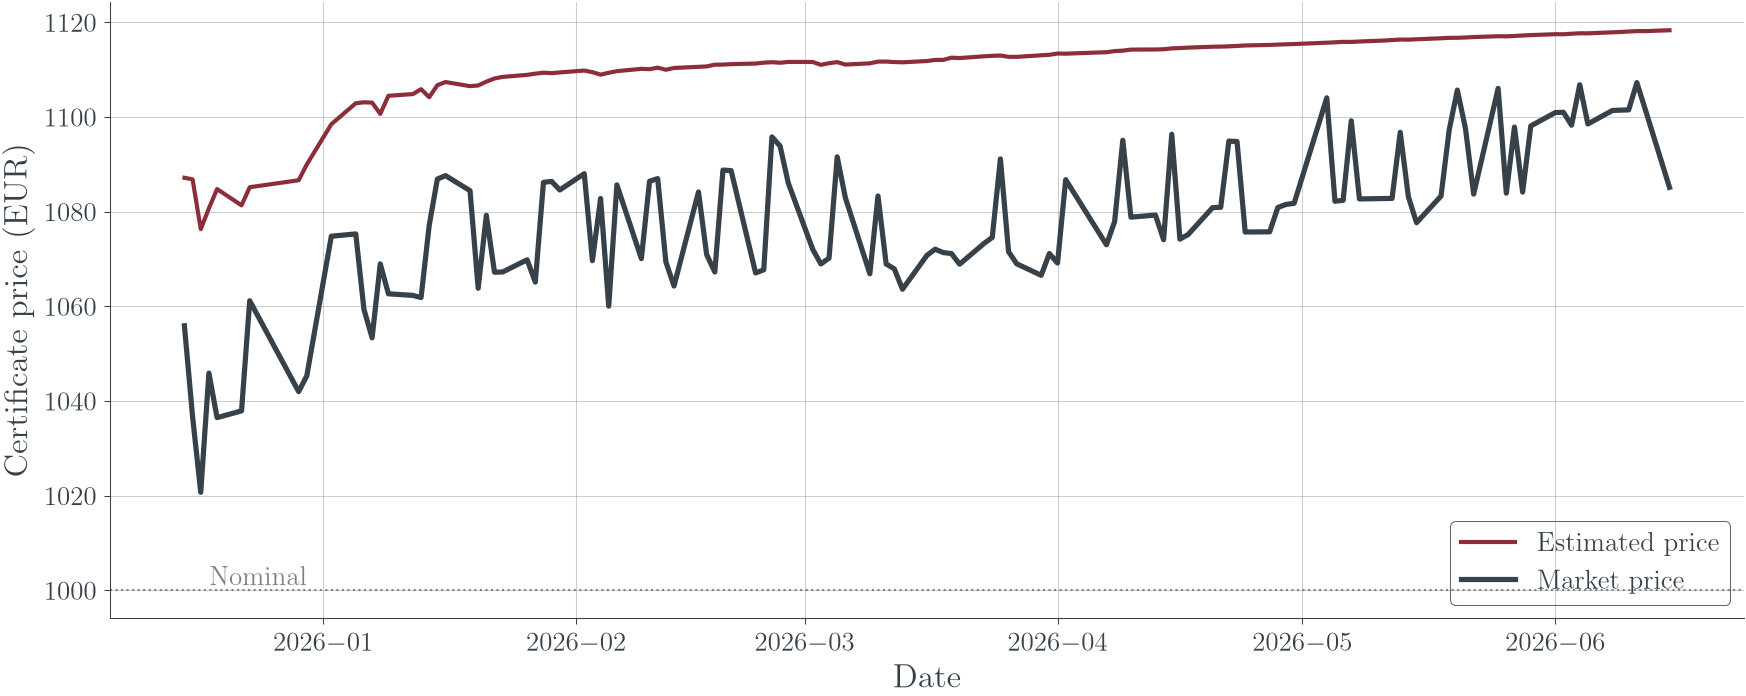

In [12]:
# Plot daily model values against observed certificate prices
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

ax.plot(
    valuation_results["Datum"],
    valuation_results["model_price"],
    label="Estimated price",
    lw=2,
)

ax.plot(
    valuation_results["Datum"],
    valuation_results["certificate_price_eur"],
    label="Market price",
    lw=2.5,
)

# Add the certificate's nominal value as a reference level
ax.axhline(
    PRODUCT_PARAMS["NOMINAL"],
    ls=":",
    color="gray",
    lw=1,
)

ax.text(
    valuation_results["Datum"].iloc[8],
    PRODUCT_PARAMS["NOMINAL"],
    "Nominal",
    va="bottom",
    ha="right",
    color="gray",
)

ax.set_ylabel("Certificate price (EUR)")
ax.set_xlabel("Date")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

# Remove unnecessary borders for a cleaner presentation
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figs/part2_valuation.pdf", bbox_inches="tight")
plt.show()

The binomial tree uses rolling historical volatility as model input, following the course guidance for the up- and down-factors. Therefore, the model price is not expected to match the observed market price exactly, since traded certificates are priced using market-implied volatility, issuer margins, funding costs, and supply-demand effects.

In [13]:
# Error metrics
metrics = error_metrics(
    valuation_results["model_price"],
    valuation_results["certificate_price_eur"],
)

metrics_df = pd.Series(metrics).to_frame("Error")
metrics_df

,Error
ME,32.096725
MAE,32.096725
RMSE,33.885315
MPE,2.990365
90%-|e|,44.197382
R²,0.539915


## Part 2, Task VI

The following code cells contain the implementation for Task VI, Sensitivity analysis.

In [14]:
# Use the most recent observation as the sensitivity-analysis snapshot
snap_row = valuation_df.iloc[-1]

snap_date = snap_row["Datum"].to_pydatetime()
sigma = snap_row["hist_volatility"]

# Extract the yield-curve parameters observed on the snapshot date
b0, b1, b2, b3, t1, t2 = snap_row[
    ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
]

# Construct the remaining term structure of daily interest rates
n_steps = idx_of(PRODUCT_PARAMS["MATURITY"], snap_date, PRODUCT_PARAMS)
horizons = np.arange(1, n_steps + 1) / PRODUCT_PARAMS["TRADING_DAYS"]

R_zero = nelson_siegel_svensson_model(
    horizons,
    b0,
    b1,
    b2,
    b3,
    t1,
    t2,
)

r_vec = zero_to_short(
    R_zero,
    1 / PRODUCT_PARAMS["TRADING_DAYS"],
)

# Evaluate the product over a broad but economically sensible range of spot prices
spot_grid = np.linspace(
    0.50 * PRODUCT_PARAMS["S_START"],
    1.40 * PRODUCT_PARAMS["S_START"],
    180,
)

greeks_spot_rows = []

# Reprice the certificate and estimate its Greeks at each hypothetical spot level
for spot in spot_grid:
    price, delta, gamma, vega = price_and_greeks(
        spot=spot,
        sigma=sigma,
        val_date=snap_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
        spot_bump_pct=0.01,
        vega_bump=0.005,
    )

    greeks_spot_rows.append(
        {
            "spot": spot,
            "price": price,
            "delta": delta,
            "gamma": gamma,
            "vega": vega,
        }
    )

# Spot-based sensitivity analysis at the selected snapshot date
greeks_spot_df = pd.DataFrame(greeks_spot_rows)

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/1027817503.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 1])


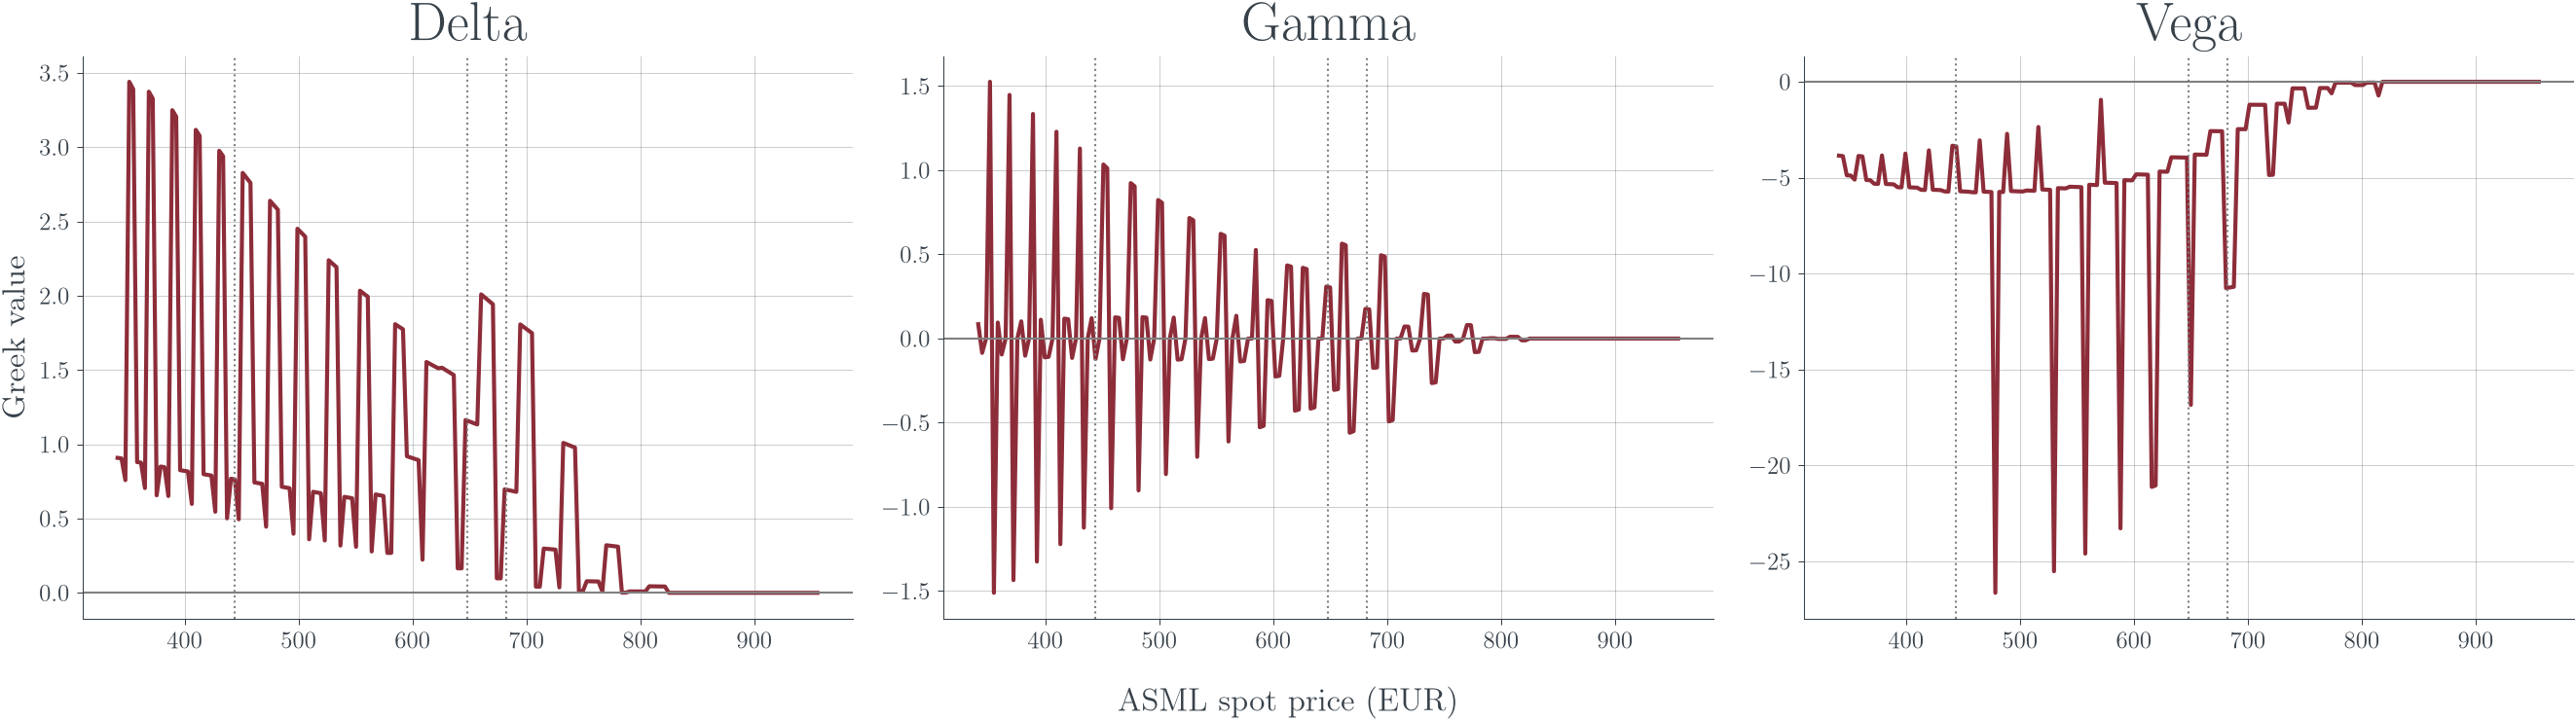

In [15]:
# Plot the raw, unsmoothed Greeks
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

greek_specs = [
    ("delta", "Delta"),
    ("gamma", "Gamma"),
    ("vega", "Vega"),
]

# Contractual ASML levels
thresholds = [
    PRODUCT_PARAMS["BARRIER"],
    PRODUCT_PARAMS["LEVELS"][1],
    PRODUCT_PARAMS["LEVELS"][0],
]

for ax, (column, title) in zip(axes, greek_specs):
    ax.plot(
        greeks_spot_df["spot"],
        greeks_spot_df[column],
        lw=2,
    )

    ax.axhline(0, color="gray", lw=1)

    for level in thresholds:
        ax.axvline(
            level,
            ls=":",
            color="gray",
            lw=1,
        )

    ax.set_title(title, fontsize=27, pad=8)
    ax.grid(alpha=0.25)
    ax.tick_params(axis="both", labelsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Greek value", fontsize=16)

fig.text(
    0.5,
    -0.01,
    "ASML spot price (EUR)",
    ha="center",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

plt.savefig(
    "figs/part2_greeks_raw.pdf",
    bbox_inches="tight",
)

plt.show()

Smooth the numerically estimated Greeks with a Savitzky-Golay filter for visualization

In [ ]:
# Define window length and polynomial order for the Savitzky-Golay filter
window_length = 51
polyorder = 3

greeks_spot_df["delta_smooth"] = savgol_filter(
    greeks_spot_df["delta"],
    window_length=window_length,
    polyorder=polyorder,
)

greeks_spot_df["gamma_smooth"] = savgol_filter(
    greeks_spot_df["gamma"],
    window_length=window_length,
    polyorder=polyorder,
)

greeks_spot_df["vega_smooth"] = savgol_filter(
    greeks_spot_df["vega"],
    window_length=window_length,
    polyorder=polyorder,
)

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/3151773490.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 1])


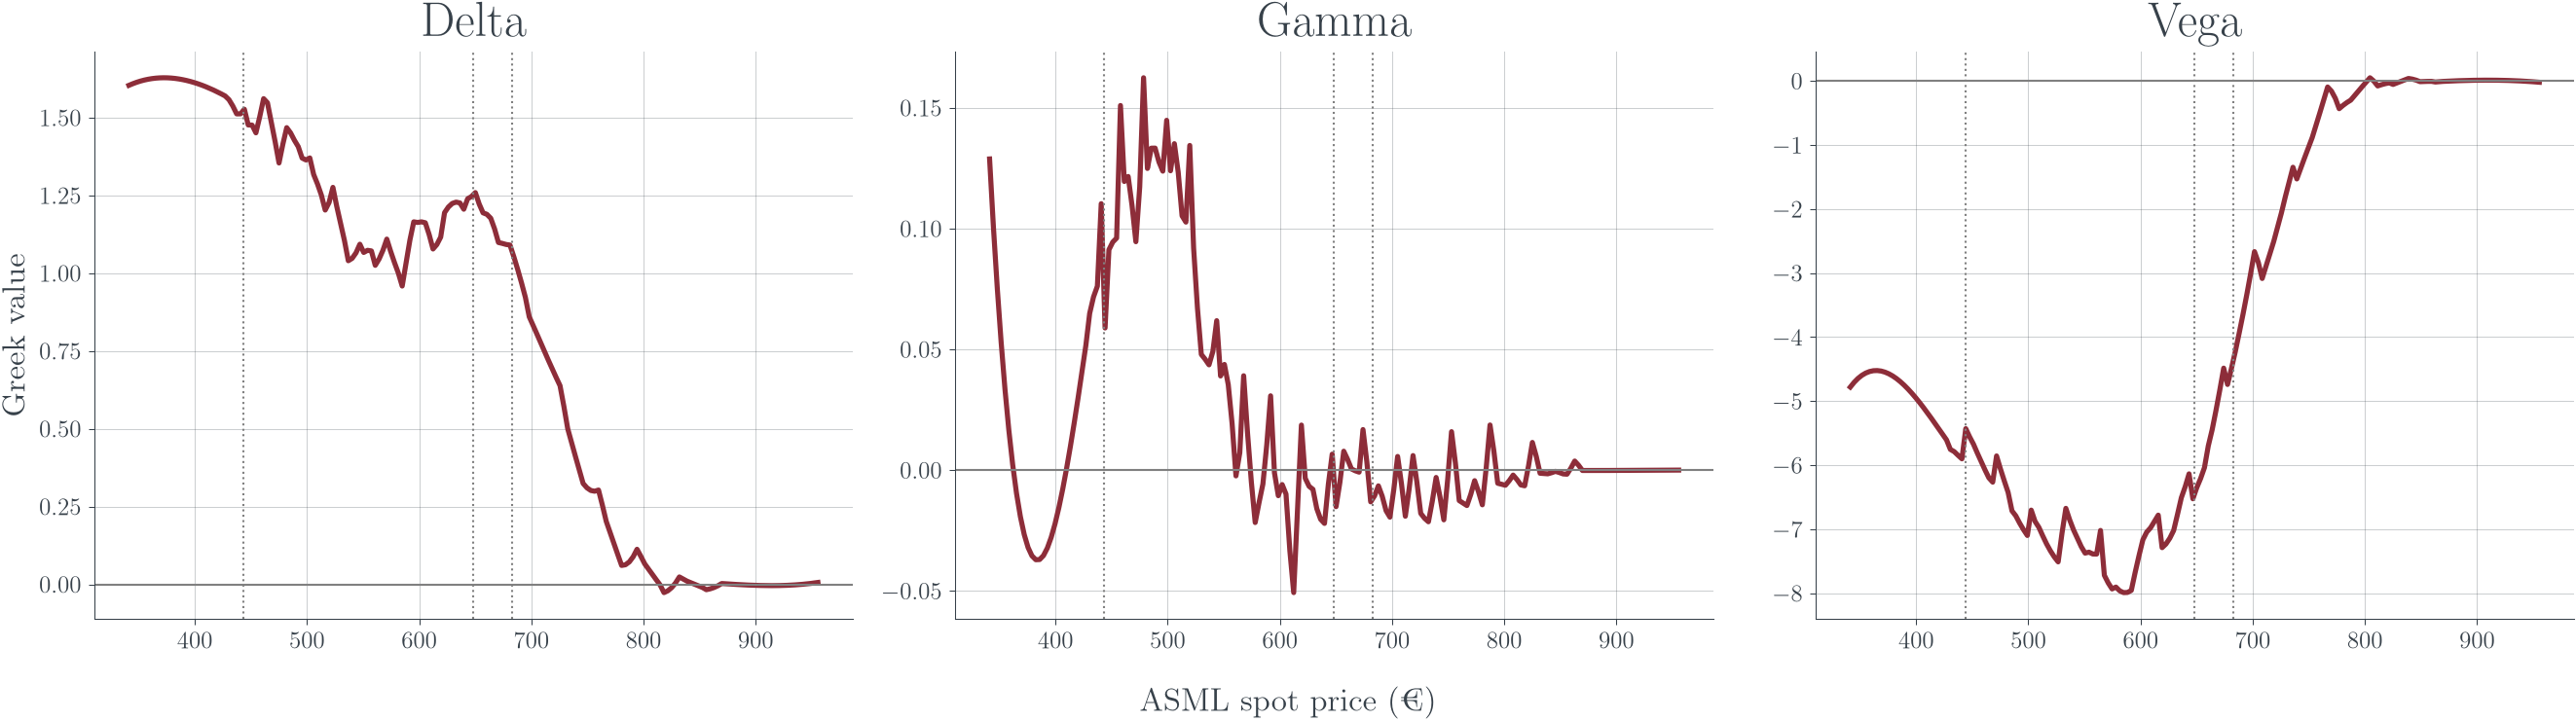

In [17]:
# Plot the smoothed Delta, Gamma, and Vega curves side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

greek_specs = [
    ("delta_smooth", "Delta"),
    ("gamma_smooth", "Gamma"),
    ("vega_smooth", "Vega"),
]

# Contractual spot levels at which the product's payoff behavior may change
thresholds = {
    "Barrier": PRODUCT_PARAMS["BARRIER"],
    "2nd autocall": PRODUCT_PARAMS["LEVELS"][1],
    "1st autocall": PRODUCT_PARAMS["LEVELS"][0],
}

# Apply the same formatting and reference levels to each Greek
for ax, (col, title) in zip(axes, greek_specs):
    ax.plot(
        greeks_spot_df["spot"],
        greeks_spot_df[col],
        lw=2.5,
    )

    ax.axhline(0, color="gray", lw=1)

    # Mark the barrier and autocall levels to support interpretation of sensitivity changes
    for _, level in thresholds.items():
        ax.axvline(
            level,
            ls=":",
            color="gray",
            lw=1,
        )

    ax.set_title(title, fontsize=24, pad=8)
    ax.grid(alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=12)

axes[0].set_ylabel("Greek value", fontsize=16)

# Add one shared x-axis label for all three panels
fig.text(
    0.5,
    -0.01,
    "ASML spot price (€)",
    ha="center",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("figs/part2_greeks.pdf", bbox_inches="tight")
plt.show()

Extending the Sensitivity anlysis, to also include Theta and Rho (not used on the poster)

In [ ]:
# Calculate the full set of price sensitivities across the spot-price range
extended_greeks_spot_rows = []

for spot in spot_grid:
    price, delta, gamma, vega, rho, theta = price_and_extended_greeks(
        spot=spot,
        sigma=sigma,
        val_date=snap_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
        spot_bump_pct=0.01,
        vega_bump=0.005,
        rho_bump=0.0001,
    )

    extended_greeks_spot_rows.append(
        {
            "spot": spot,
            "price": price,
            "delta": delta,
            "gamma": gamma,
            "vega": vega,
            "rho": rho,
            "theta": theta,
        }
    )

extended_greeks_spot_df = pd.DataFrame(extended_greeks_spot_rows)

extended_greeks_spot_df[
    ["price", "delta", "gamma", "vega", "rho", "theta"]
].describe()

,price,delta,gamma,vega,rho,theta
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,967.042535,0.830043,0.020058,-3.743367,-1.541558,0.691103
std,162.728492,0.945287,0.434772,4.635442,1.582743,7.408355
min,598.965552,0.000000,-1.510475,-26.643699,-4.942170,-18.078913
25%,844.178897,0.009327,-0.073140,-5.493651,-2.787471,-6.181033
50%,1016.251109,0.648733,0.000000,-3.800275,-0.810745,0.097216
75%,1117.629507,1.155761,0.088022,-0.044847,-0.525126,8.276995
max,1118.339834,3.440236,1.525593,0.000000,1.146927,19.826766


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/3486614913.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


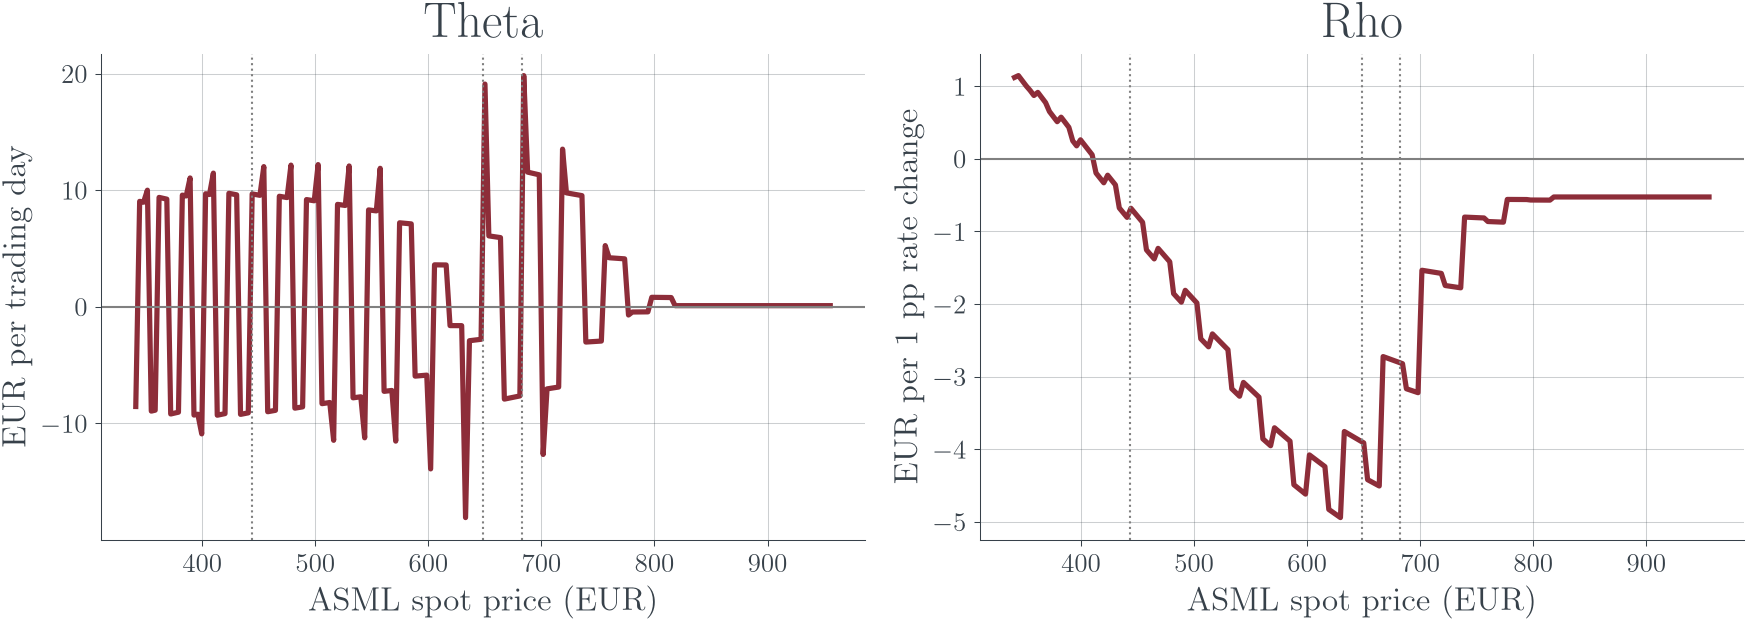

In [19]:
# Plot Theta and Rho across the spot-price range
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

axes[0].plot(
    extended_greeks_spot_df["spot"],
    extended_greeks_spot_df["theta"],
    lw=2.5,
)
axes[0].set_title("Theta", fontsize=24, pad=8)
axes[0].set_ylabel("EUR per trading day")

axes[1].plot(
    extended_greeks_spot_df["spot"],
    extended_greeks_spot_df["rho"],
    lw=2.5,
)
axes[1].set_title("Rho", fontsize=24, pad=8)
axes[1].set_ylabel("EUR per 1 pp rate change")

# Apply consistent formatting and mark economically relevant contract levels
for ax in axes:
    for level in (
        PRODUCT_PARAMS["BARRIER"],
        PRODUCT_PARAMS["LEVELS"][1],
        PRODUCT_PARAMS["LEVELS"][0],
    ):
        ax.axvline(level, ls=":", color="gray", lw=1)

    ax.axhline(0, color="gray", lw=1)
    ax.set_xlabel("ASML spot price (EUR)")
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Part 2, Task VII

In [20]:
# Number of certificates to replicate (obviously only one)
N_CERT = 1

dt = 1 / PRODUCT_PARAMS["TRADING_DAYS"]

portfolio_vals = []
bond_vals = []
equity_vals = []
prod_vals = []
hedge_shares = []
dates = []
deltas = []

# Initialize on the first valuation date
row0 = valuation_df.iloc[0]

val_date = row0["Datum"].to_pydatetime()
spot = row0["underlying_price"]
sigma0 = row0["hist_volatility"]

# Build the remaining daily term structure on the first valuation date
b0, b1, b2, b3, t1, t2 = row0[
    ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
]

n_steps = idx_of(
    PRODUCT_PARAMS["MATURITY"],
    val_date,
    PRODUCT_PARAMS,
)

horizons = (
    np.arange(1, n_steps + 1)
    / PRODUCT_PARAMS["TRADING_DAYS"]
)

R_zero = nelson_siegel_svensson_model(
    horizons,
    b0,
    b1,
    b2,
    b3,
    t1,
    t2,
)

r_vec = zero_to_short(
    R_zero,
    dt,
)

# Price and Delta on the first valuation date
pv0, delta0, *_ = price_and_greeks(
    spot=spot,
    sigma=sigma0,
    val_date=val_date,
    r_vec=r_vec,
    params=PRODUCT_PARAMS,
    spot_bump_pct=0.01,
    vega_bump=0.005,
)

# Initial stock and cash positions
shares = delta0 * N_CERT
cash = pv0 * N_CERT - shares * spot

# Store day 0
prod_vals.append(pv0 * N_CERT)
equity_vals.append(shares * spot)
bond_vals.append(cash)
portfolio_vals.append(cash + shares * spot)
hedge_shares.append(shares)
dates.append(val_date)
deltas.append(delta0)

In [21]:
# Daily self-financing rebalancing loop
for _, row in valuation_df.iloc[1:].iterrows():
    val_date = row["Datum"].to_pydatetime()
    spot = row["underlying_price"]
    sigma_daily = row["hist_volatility"]

    # Build the remaining daily term structure
    b0, b1, b2, b3, t1, t2 = row[
        ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
    ]

    n_steps = idx_of(
        PRODUCT_PARAMS["MATURITY"],
        val_date,
        PRODUCT_PARAMS,
    )

    horizons = (
        np.arange(1, n_steps + 1)
        / PRODUCT_PARAMS["TRADING_DAYS"]
    )

    R_zero = nelson_siegel_svensson_model(
        horizons,
        b0,
        b1,
        b2,
        b3,
        t1,
        t2,
    )

    r_vec = zero_to_short(
        R_zero,
        dt,
    )

    # Accrue the cash position at the current short rate
    r_short = r_vec[0]
    cash *= np.exp(r_short * dt)

    # Reprice the certificate and compute the new Delta
    pv, delta_new, *_ = price_and_greeks(
        spot=spot,
        sigma=sigma_daily,
        val_date=val_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
        spot_bump_pct=0.01,
        vega_bump=0.005,
    )

    # Rebalance the stock position self-financingly
    target_shares = delta_new * N_CERT
    d_shares = target_shares - shares

    cash -= d_shares * spot
    shares = target_shares

    # Store values
    prod_vals.append(pv * N_CERT)
    equity_vals.append(shares * spot)
    bond_vals.append(cash)
    portfolio_vals.append(cash + shares * spot)
    hedge_shares.append(shares)
    dates.append(val_date)
    deltas.append(delta_new)

In [22]:
replication_dynamic_df = pd.DataFrame(
    {
        "Datum": dates,
        "product_value": prod_vals,
        "equity_value": equity_vals,
        "bond_value": bond_vals,
        "portfolio_value": portfolio_vals,
        "shares": hedge_shares,
        "delta": deltas,
    }
)

replication_dynamic_df["equity_fraction"] = (
    replication_dynamic_df["equity_value"]
    / replication_dynamic_df["portfolio_value"]
)

replication_dynamic_df["bond_fraction"] = (
    replication_dynamic_df["bond_value"]
    / replication_dynamic_df["portfolio_value"]
)

replication_dynamic_df.head()

,Datum,product_value,equity_value,bond_value,portfolio_value,shares,delta,equity_fraction,bond_fraction
0,2025-12-15,1087.170080,153.856300,933.313780,1087.170080,0.165259,0.165259,0.141520,0.858480
1,2025-12-16,1086.833238,128.043407,955.497174,1083.540580,0.140924,0.140924,0.118171,0.881829
2,2025-12-17,1076.325098,251.702194,827.036512,1078.738706,0.287989,0.287989,0.233330,0.766670
3,2025-12-18,1080.715685,221.317294,862.871018,1084.188313,0.247919,0.247919,0.204132,0.795868
4,2025-12-19,1084.786931,326.070172,760.391770,1086.461943,0.361657,0.361657,0.300121,0.699879


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/1248196040.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


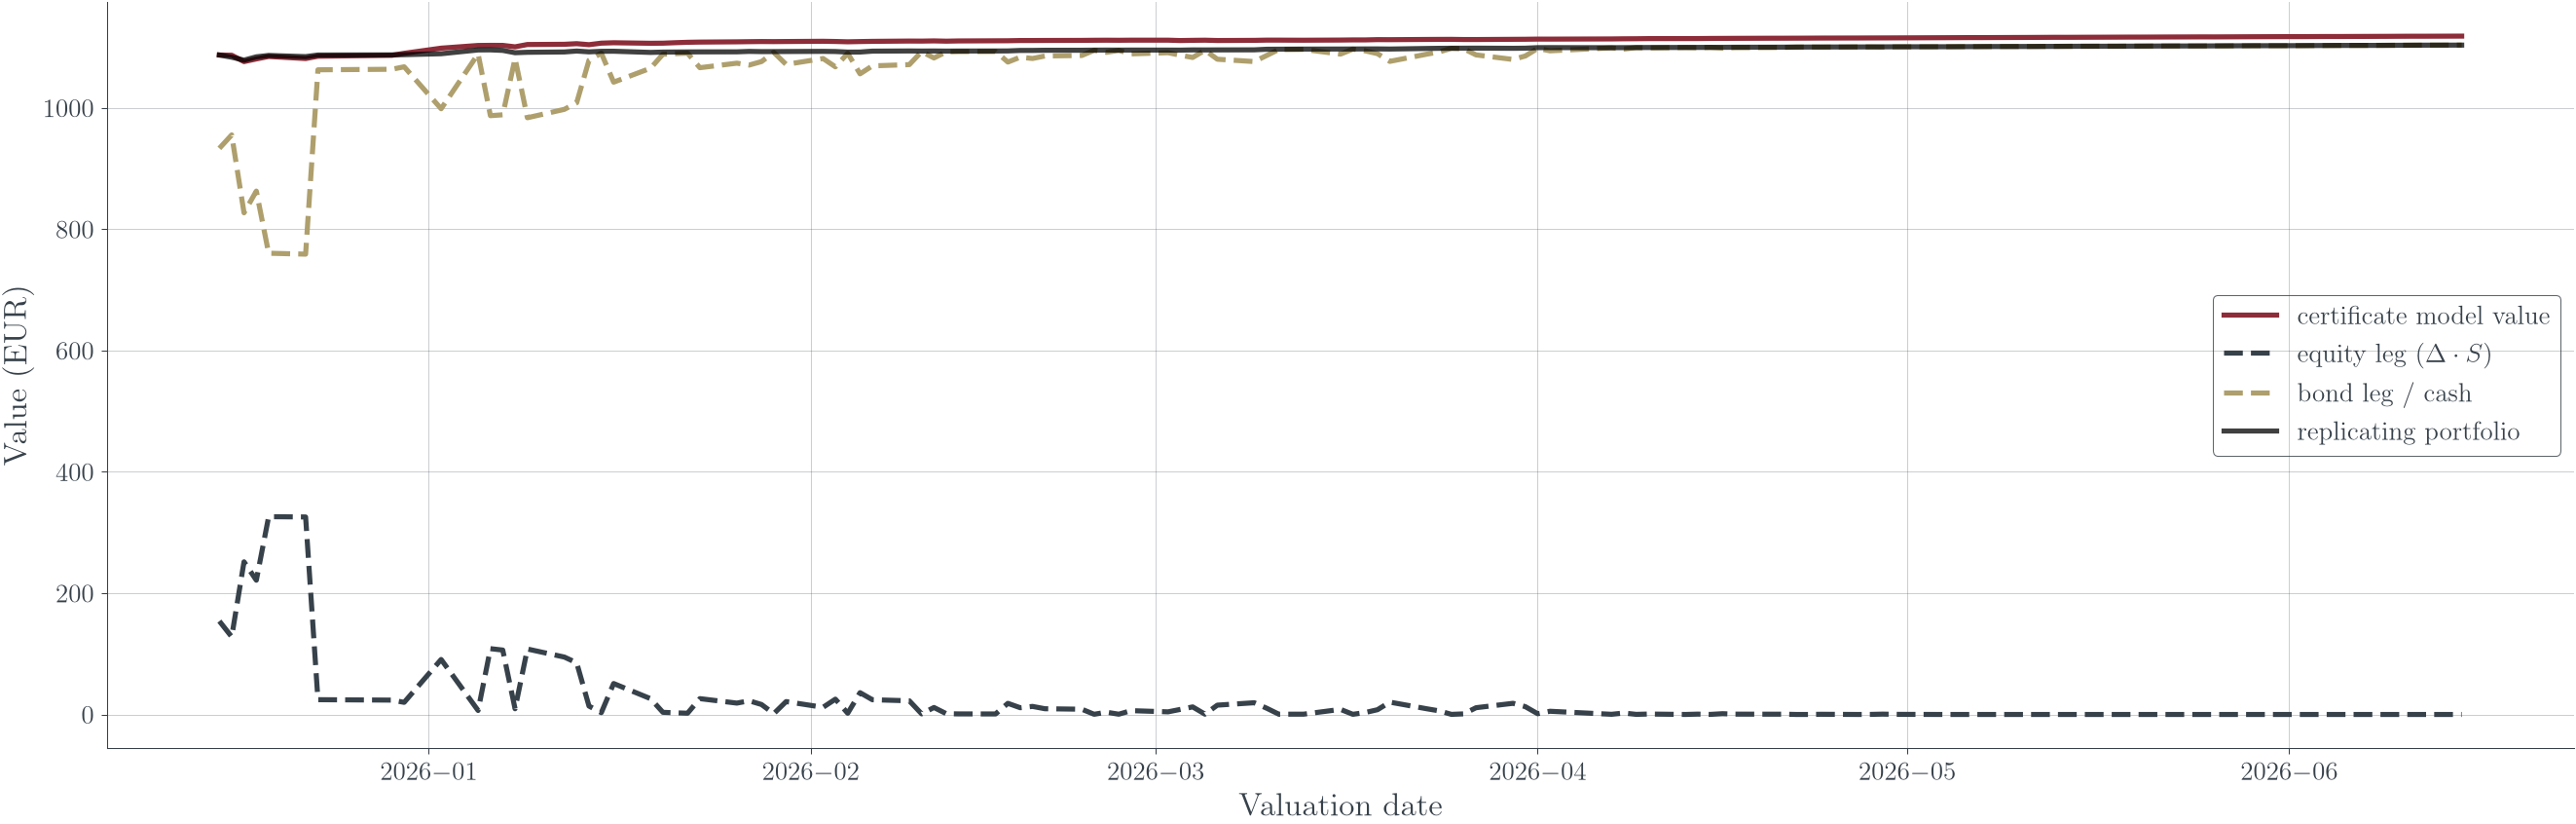

In [23]:
fig, ax = plt.subplots(figsize=(18, 6), dpi=150)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["product_value"],
    label="certificate model value",
    lw=2.5,
)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["equity_value"],
    "--",
    label=r"equity leg ($\Delta \cdot S$)",
    lw=2.5,
)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["bond_value"],
    "--",
    label="bond leg / cash",
    lw=2.5,
)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["portfolio_value"],
    color="k",
    alpha=0.75,
    label="replicating portfolio",
    lw=2.5,
)

ax.set_xlabel("Valuation date")
ax.set_ylabel("Value (EUR)")
ax.grid(alpha=0.25)
ax.legend(loc="best")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figs/part2_replication_dynamic.pdf",
    bbox_inches="tight",
)

plt.show()

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/137661756.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


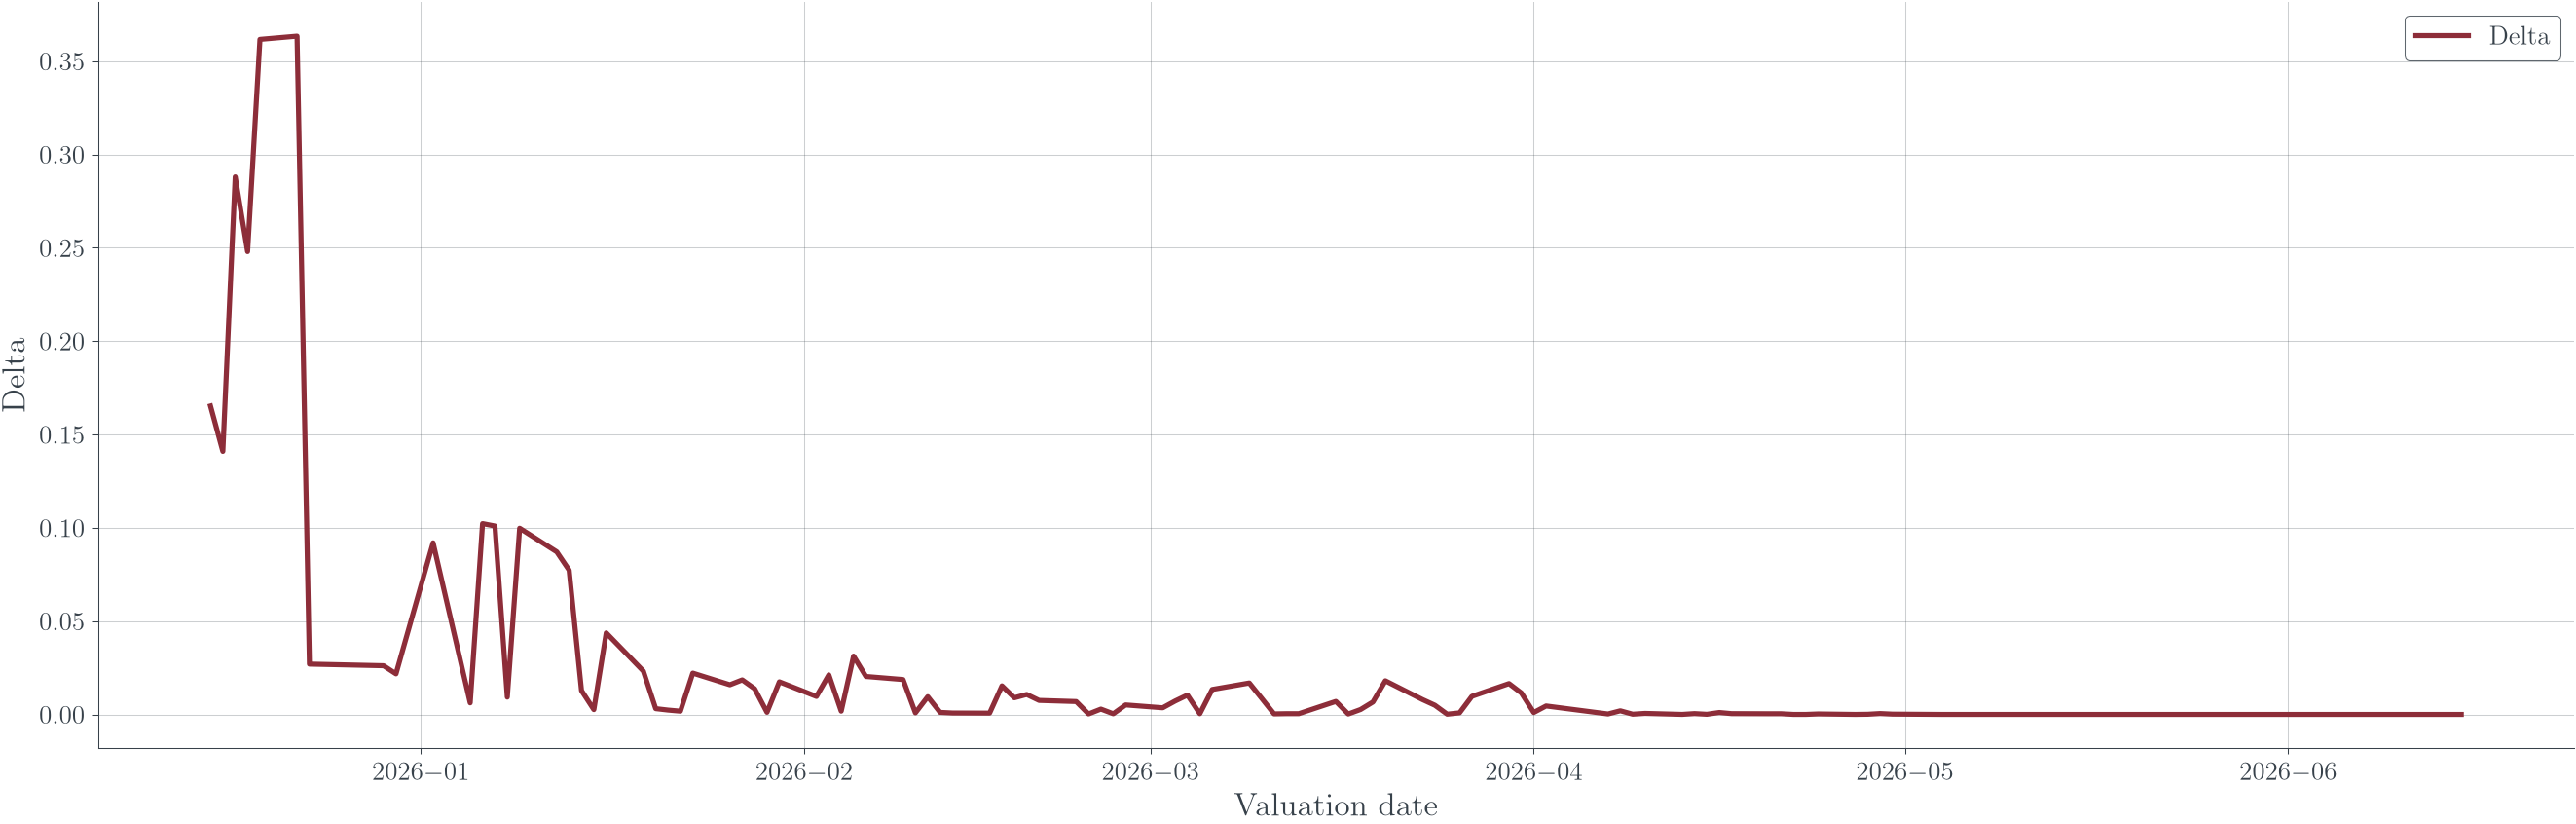

In [24]:
fig, ax = plt.subplots(figsize=(18, 6), dpi=150)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["delta"],
    label="Delta",
    lw=2.5,
)

ax.set_xlabel("Valuation date")
ax.set_ylabel("Delta")
ax.grid(alpha=0.25)
ax.legend(loc="best")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figs/part2_replication_delta.pdf",
    bbox_inches="tight",
)

plt.show()

In [25]:
metrics_repl = error_metrics(
    np.array(replication_dynamic_df["product_value"]),
    np.array(replication_dynamic_df["portfolio_value"]),
)

pd.Series(metrics_repl).to_frame("Error")

,Error
ME,13.692125
MAE,13.910097
RMSE,14.393818
MPE,1.247384
90%-|e|,16.378476
R²,0.185144


In [26]:
# Equity fraction as a function of the ASML spot price
replication_spot_df = greeks_spot_df[
    [
        "spot",
        "price",
        "delta_smooth",
    ]
].copy()

# Local value invested in ASML shares
replication_spot_df["equity_value"] = (
    replication_spot_df["delta_smooth"]
    * replication_spot_df["spot"]
)

# Equity fraction of the local replicating portfolio
replication_spot_df["equity_fraction"] = (
    replication_spot_df["equity_value"]
    / replication_spot_df["price"]
)

replication_spot_df.head()

,spot,price,delta_smooth,equity_value,equity_fraction
0,341.250000,598.965552,1.603878,547.323285,0.913781
1,344.681564,602.578087,1.609096,554.625880,0.920422
2,348.113128,605.181497,1.613654,561.734293,0.928208
3,351.544693,607.784907,1.617566,568.646869,0.935605
4,354.976257,629.246297,1.620847,575.362155,0.914367


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_15984/1142718730.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


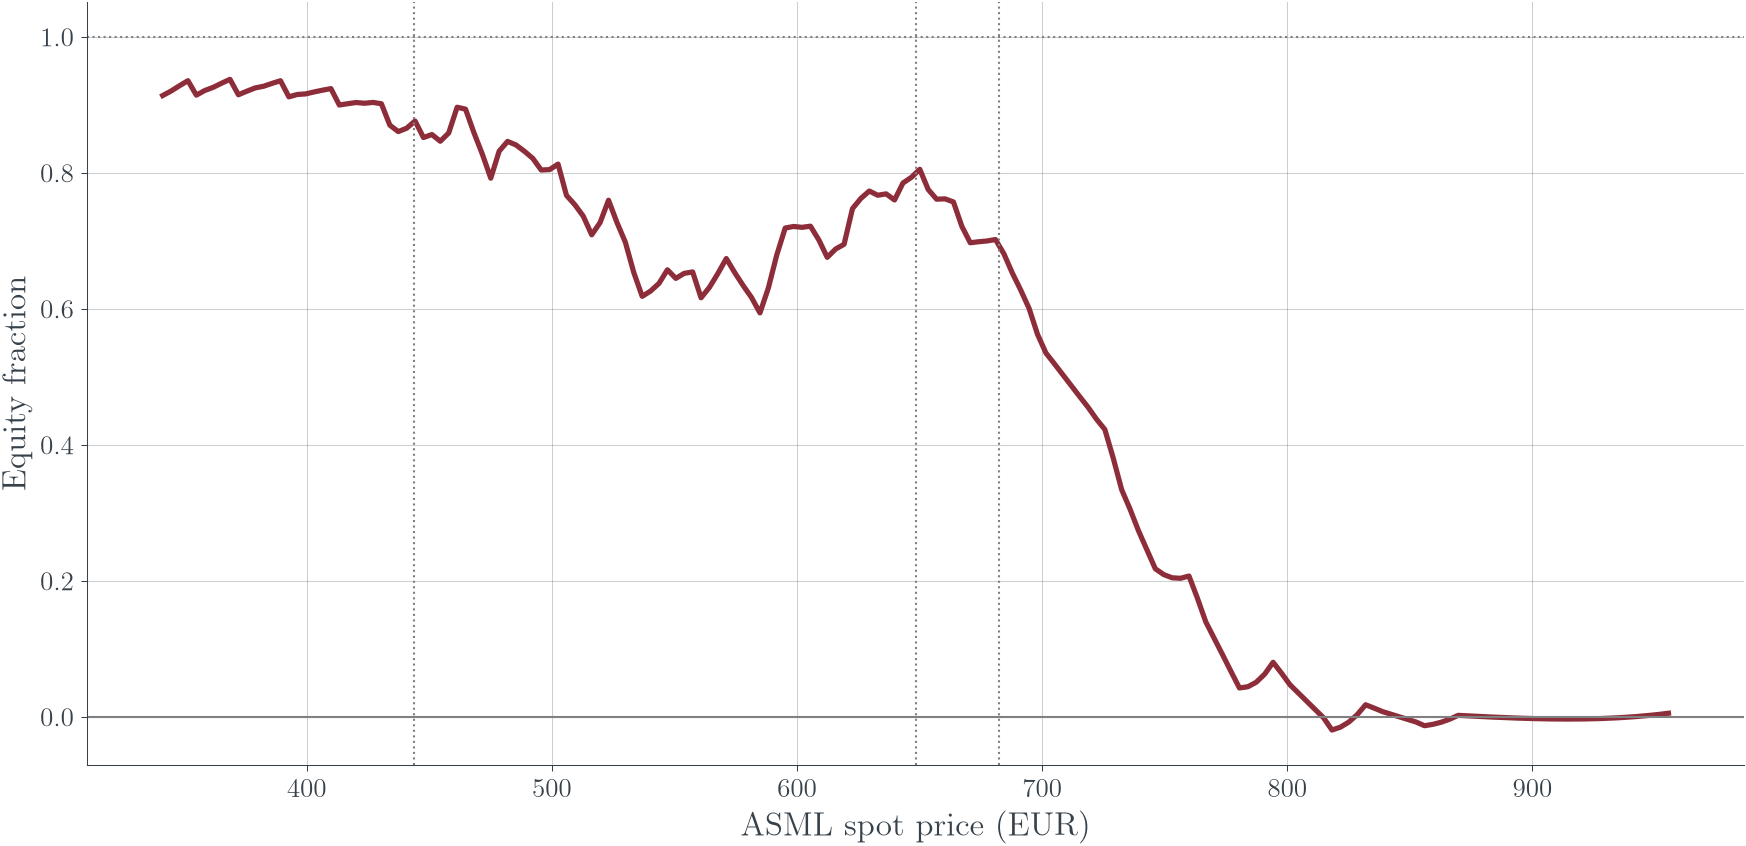

In [27]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

ax.plot(
    replication_spot_df["spot"],
    replication_spot_df["equity_fraction"],
    lw=2.5,
)

# Contractual reference levels
thresholds = {
    "Barrier": PRODUCT_PARAMS["BARRIER"],
    "2nd autocall": PRODUCT_PARAMS["LEVELS"][1],
    "1st autocall": PRODUCT_PARAMS["LEVELS"][0],
}

for _, level in thresholds.items():
    ax.axvline(
        level,
        ls=":",
        color="gray",
        lw=1,
    )

ax.axhline(0, color="gray", lw=1)
ax.axhline(1, color="gray", lw=1, ls=":")

ax.set_xlabel("ASML spot price (EUR)")
ax.set_ylabel("Equity fraction")
ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figs/part2_equity_fraction.pdf",
    bbox_inches="tight",
)

plt.show()